# Retail Intelligence: Exploratory Data Analysis

This notebook explores the cleaned retail analysis outputs, including customer RFM segments, cohort retention, regional performance, product categories, promotions, and data-quality checks.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# Resolve the notebook folder so it works when launched from another directory.
DATA_DIR = Path.cwd()
if not (DATA_DIR / 'Day_2 files').is_dir() or not (DATA_DIR / 'Day_3 files').is_dir():
    DATA_DIR = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'Day_2 files').is_dir() and (path / 'Day_3 files').is_dir()), Path.cwd())

source_dirs = [DATA_DIR / 'Day_2 files', DATA_DIR / 'Day_3 files']
csv_paths = sorted(path for source_dir in source_dirs for path in source_dir.glob('*.csv'))
print(f'Data folder: {DATA_DIR}')
print(f'CSV files found in Day 2 and Day 3: {len(csv_paths)}')
pd.DataFrame({'file': [path.relative_to(DATA_DIR) for path in csv_paths]})

Data folder: e:\B. Data Analyst\2. Bootcamp\Project-1( Retail Intelligence )\2. Clean Data\Project 1
CSV files found in Day 2 and Day 3: 13


,file
0,Day_2 files\Category mix for each region.csv
1,Day_2 files\Check if promotions increased sale...
2,"Day_2 files\Customer spend tiers (High, Medium..."
3,Day_2 files\Customers who spend above average.csv
4,Day_2 files\Data Quality Check(null).csv
5,Day_2 files\Data Quality Check(Wrong).csv
6,Day_2 files\Products with falling sales month ...
7,Day_2 files\Rank stores within each region.csv
8,Day_2 files\Repeat purchase rate.csv
9,Day_2 files\Revenue by region and store type.csv


In [5]:
datasets = {}
dataset_sources = {}
load_errors = {}
for path in csv_paths:
    try:
        datasets[path.stem] = pd.read_csv(path)
        dataset_sources[path.stem] = path.relative_to(DATA_DIR)
    except Exception as error:
        load_errors[str(path.relative_to(DATA_DIR))] = str(error)

dataset_overview = pd.DataFrame([
    {
        'dataset': name,
        'source': str(dataset_sources.get(name, '')),
        'rows': len(frame),
        'columns': len(frame.columns),
        'missing_values': int(frame.isna().sum().sum()),
        'duplicate_rows': int(frame.duplicated().sum())
    }
    for name, frame in datasets.items()
])
display(dataset_overview.sort_values('rows', ascending=False))
if load_errors:
    print('Files that could not be loaded:', load_errors)

,dataset,source,rows,columns,missing_values,duplicate_rows
6,Products with falling sales month over month,Day_2 files\Products with falling sales month ...,5556,9,0,0
12,RFM segment summary,Day_3 files\RFM segment summary.csv,5000,10,0,0
2,"Customer spend tiers (High, Medium, Low)","Day_2 files\Customer spend tiers (High, Medium...",5000,4,0,0
3,Customers who spend above average,Day_2 files\Customers who spend above average.csv,2413,4,0,0
11,Cohort retention data,Day_3 files\Cohort retention data.csv,1711,5,0,0
7,Rank stores within each region,Day_2 files\Rank stores within each region.csv,50,5,0,0
0,Category mix for each region,Day_2 files\Category mix for each region.csv,21,5,0,0
5,Data Quality Check(Wrong),Day_2 files\Data Quality Check(Wrong).csv,10,3,0,0
4,Data Quality Check(null),Day_2 files\Data Quality Check(null).csv,10,3,0,0
9,Revenue by region and store type,Day_2 files\Revenue by region and store type.csv,9,5,0,0


## Monthly Revenue Trend

Aggregate monthly revenue across products and visualize the overall retail revenue trend.

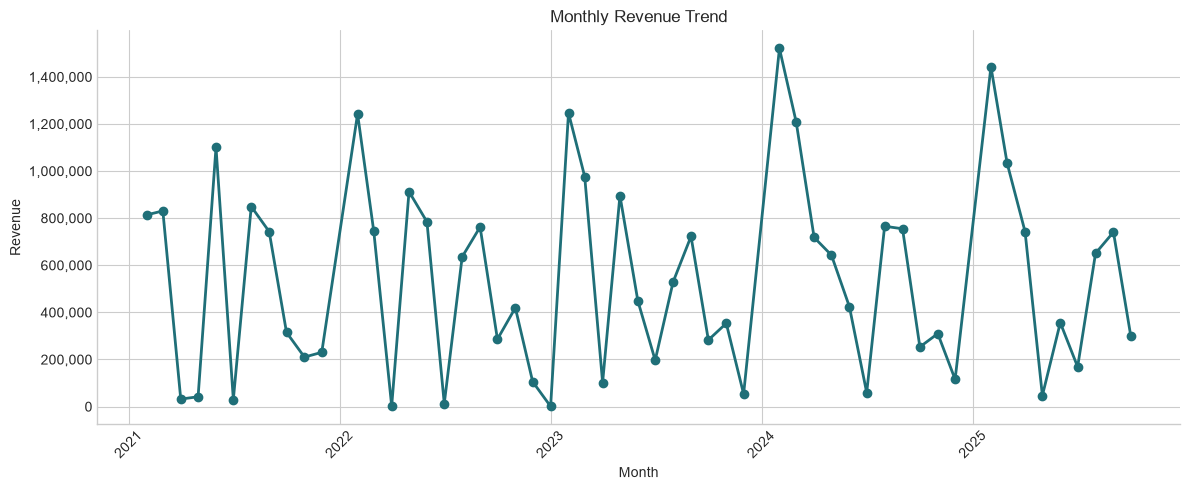

In [4]:
import matplotlib.ticker as mtick

monthly_sales_key = 'Products with falling sales month over month'
if monthly_sales_key in datasets:
    monthly_sales = datasets[monthly_sales_key].copy()
    monthly_sales['sales_month'] = pd.to_datetime(monthly_sales['sales_month'])
    monthly_revenue = (monthly_sales.groupby('sales_month', as_index=False)['monthly_revenue']
                       .sum()
                       .sort_values('sales_month'))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_revenue['sales_month'], monthly_revenue['monthly_revenue'],
            color='#1f6f78', marker='o', linewidth=2)
    ax.set_title('Monthly Revenue Trend')
    ax.set_xlabel('Month')
    ax.set_ylabel('Revenue')
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print(f'Expected dataset not found: {monthly_sales_key}')

## Revenue by Region

Aggregate revenue across store types and compare total revenue by region.

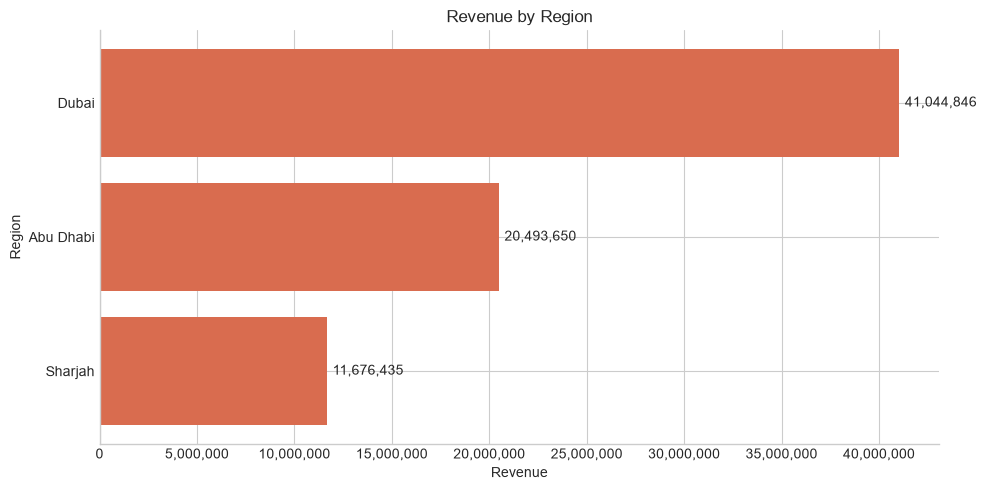

In [5]:
region_revenue_key = 'Revenue by region and store type'
if region_revenue_key in datasets:
    region_revenue = (datasets[region_revenue_key]
                      .groupby('region', as_index=False)['revenue']
                      .sum()
                      .sort_values('revenue'))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(region_revenue['region'], region_revenue['revenue'], color='#d96c4f')
    ax.set_title('Revenue by Region')
    ax.set_xlabel('Revenue')
    ax.set_ylabel('Region')
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.bar_label(bars, fmt='{:,.0f}', padding=4)
    plt.tight_layout()
    plt.show()
else:
    print(f'Expected dataset not found: {region_revenue_key}')

## Top 10 Products

Aggregate product revenue and display the ten highest-revenue products.

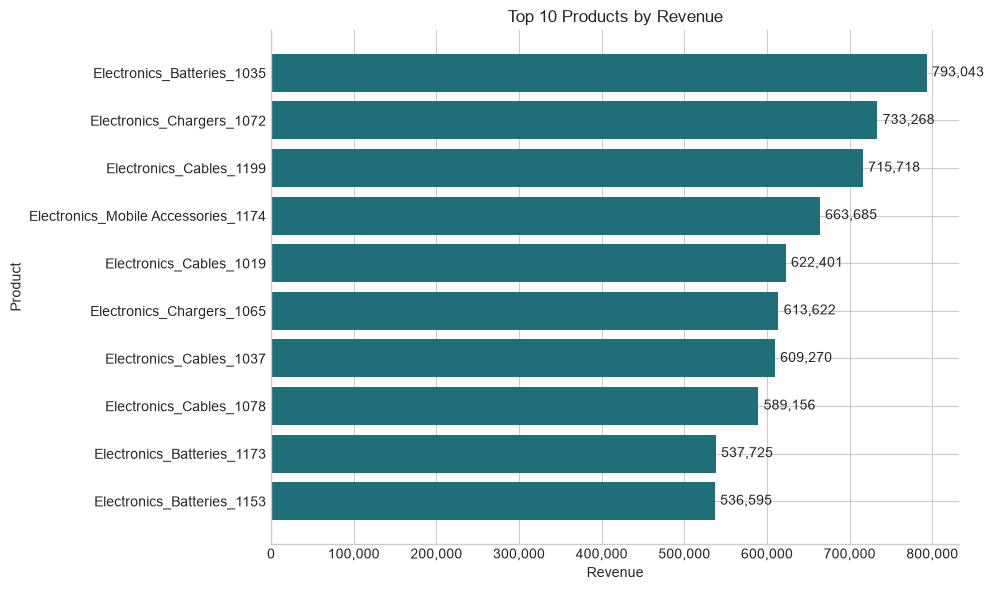

In [6]:
product_revenue_key = 'Products with falling sales month over month'
if product_revenue_key in datasets:
    product_revenue = (datasets[product_revenue_key]
                       .groupby('sku_name', as_index=False)['monthly_revenue']
                       .sum()
                       .nlargest(10, 'monthly_revenue')
                       .sort_values('monthly_revenue'))

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(product_revenue['sku_name'], product_revenue['monthly_revenue'], color='#1f6f78')
    ax.set_title('Top 10 Products by Revenue')
    ax.set_xlabel('Revenue')
    ax.set_ylabel('Product')
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
    ax.spines[['top', 'right']].set_visible(False)
    ax.bar_label(bars, fmt='{:,.0f}', padding=4)
    plt.tight_layout()
    plt.show()
else:
    print(f'Expected dataset not found: {product_revenue_key}')

## RFM Customer Segments

Show the share of customers in each RFM segment.

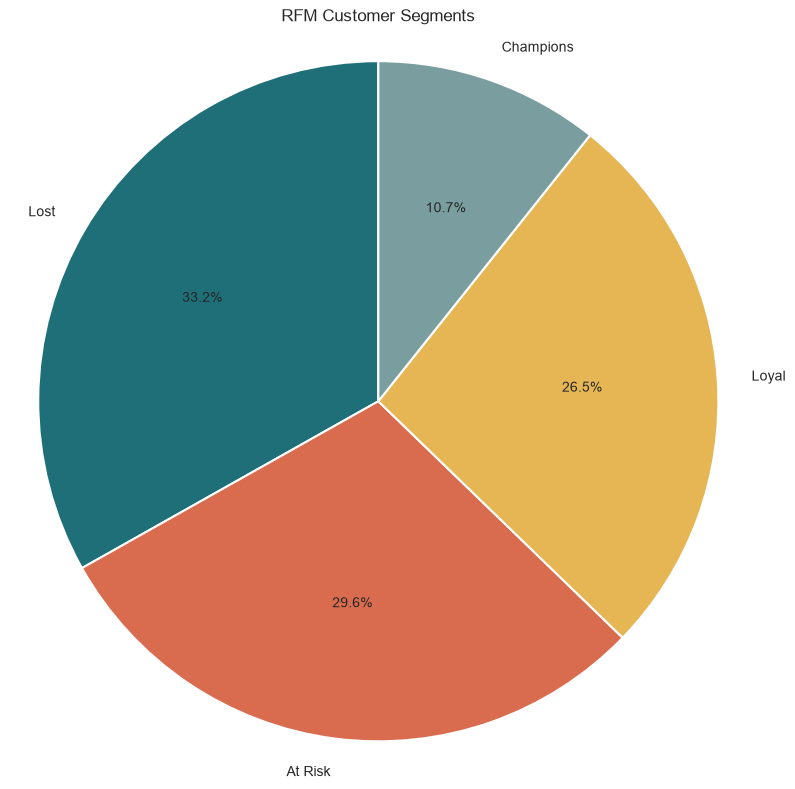

In [7]:
rfm_pie_key = 'RFM segment summary'
if rfm_pie_key in datasets:
    rfm_segment_counts = (datasets[rfm_pie_key]
                          .groupby('customer_segment')['cust_id']
                          .nunique()
                          .sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(rfm_segment_counts, labels=rfm_segment_counts.index,
           autopct='%1.1f%%', startangle=90,
           colors=['#1f6f78', '#d96c4f', '#e6b655', '#7a9e9f', '#b65d4d'],
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title('RFM Customer Segments')
    ax.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print(f'Expected dataset not found: {rfm_pie_key}')

## Cohort Retention Heatmap

Visualize customer retention by signup cohort and months since signup.

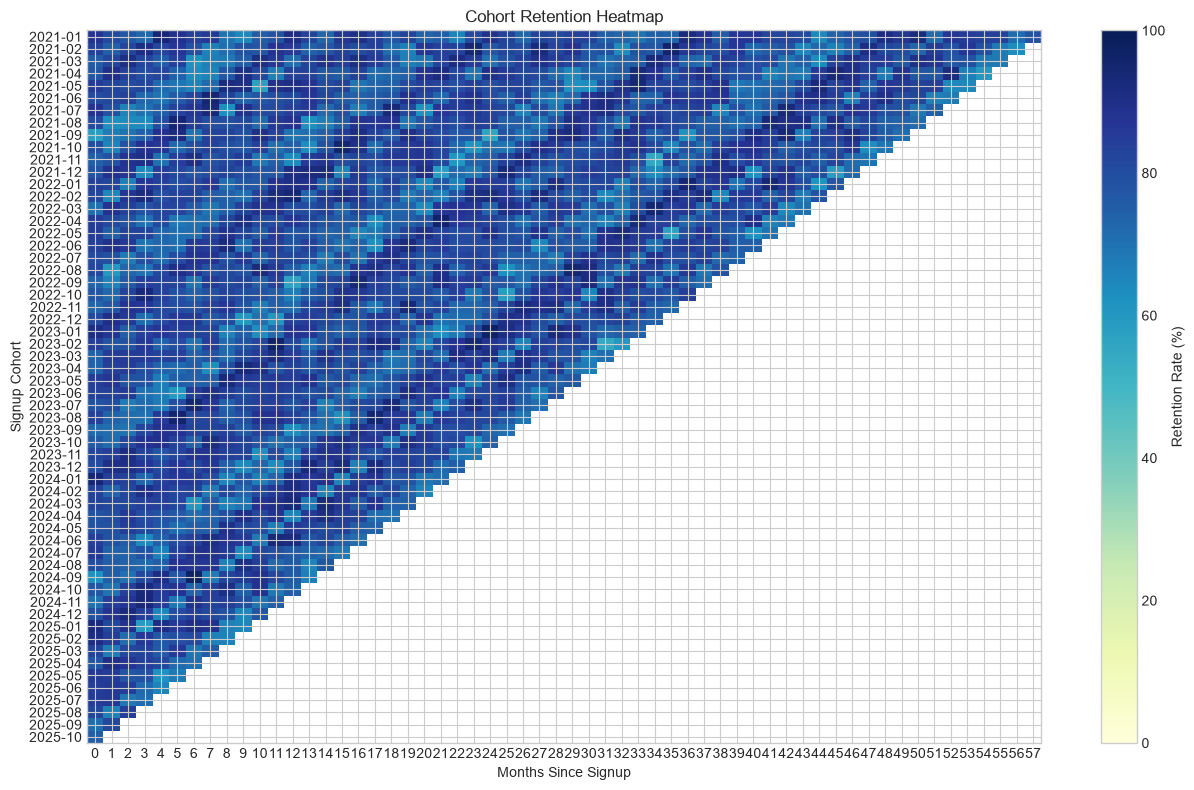

In [8]:
cohort_heatmap_key = 'Cohort retention data'
if cohort_heatmap_key in datasets:
    cohort_heatmap = datasets[cohort_heatmap_key].copy()
    cohort_heatmap['cohort_month'] = pd.to_datetime(cohort_heatmap['cohort_month'])
    retention_matrix = (cohort_heatmap
                        .pivot(index='cohort_month', columns='months_since_signup', values='retention_rate_pct')
                        .sort_index())

    fig, ax = plt.subplots(figsize=(13, 8))
    image = ax.imshow(retention_matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
    ax.set_title('Cohort Retention Heatmap')
    ax.set_xlabel('Months Since Signup')
    ax.set_ylabel('Signup Cohort')
    ax.set_xticks(range(len(retention_matrix.columns)), retention_matrix.columns)
    ax.set_yticks(range(len(retention_matrix.index)), retention_matrix.index.strftime('%Y-%m'))
    fig.colorbar(image, ax=ax, label='Retention Rate (%)')
    plt.tight_layout()
    plt.show()
else:
    print(f'Expected dataset not found: {cohort_heatmap_key}')

## Executive Summary PDF

Generate a one-page executive summary answering the three business questions: where revenue is concentrated, whether promotions are effective, and which customers need action.

In [6]:
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle

region_summary = (datasets['Revenue by region and store type']
                  .groupby('region')['revenue'].sum().sort_values(ascending=False))
category_summary = (datasets['Top 5 product categories by revenue']
                    .sort_values('revenue', ascending=False))
promotion_summary = datasets['Check if promotions increased sales'].set_index('sales_period')
rfm_summary = datasets['RFM segment summary']['customer_segment'].value_counts()
cohort_summary = datasets['Cohort retention data'].copy()
cohort_summary['cohort_month'] = pd.to_datetime(cohort_summary['cohort_month'])
month_12_retention = cohort_summary.loc[cohort_summary['months_since_signup'] == 12, 'retention_rate_pct'].mean()
promo_avg = promotion_summary.loc['Promotion Period', 'avg_revenue_per_transaction']
nonpromo_avg = promotion_summary.loc['Non-Promotion Period', 'avg_revenue_per_transaction']
promo_uplift = (promo_avg / nonpromo_avg - 1) * 100
at_risk_or_lost = (rfm_summary.get('At Risk', 0) + rfm_summary.get('Lost', 0)) / rfm_summary.sum() * 100

pdf_path = DATA_DIR / 'retail_executive_summary.pdf'
doc = SimpleDocTemplate(str(pdf_path), pagesize=letter, rightMargin=34, leftMargin=34, topMargin=28, bottomMargin=28)
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name='SummaryTitle', parent=styles['Title'], fontName='Helvetica-Bold', fontSize=18, leading=21, textColor=colors.HexColor('#173f4a'), alignment=TA_CENTER, spaceAfter=3))
styles.add(ParagraphStyle(name='SummarySub', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.HexColor('#52666b'), alignment=TA_CENTER, spaceAfter=10))
styles.add(ParagraphStyle(name='Section', parent=styles['Heading2'], fontName='Helvetica-Bold', fontSize=10.5, leading=12, textColor=colors.HexColor('#d96c4f'), spaceBefore=5, spaceAfter=3))
styles.add(ParagraphStyle(name='BodySmall', parent=styles['BodyText'], fontSize=8.3, leading=10.5, textColor=colors.HexColor('#26383d'), spaceAfter=2))
styles.add(ParagraphStyle(name='Kpi', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=13, leading=15, alignment=TA_CENTER, textColor=colors.HexColor('#173f4a')))
styles.add(ParagraphStyle(name='KpiLabel', parent=styles['Normal'], fontSize=7.5, leading=9, alignment=TA_CENTER, textColor=colors.HexColor('#52666b')))

story = [Paragraph('Retail Intelligence Executive Summary', styles['SummaryTitle']), Paragraph('Project 1 | Evidence from Day 2 and Day 3 analysis outputs', styles['SummarySub'])]
kpis = [
    [Paragraph(f"{region_summary.iloc[0] / 1_000_000:.1f}M", styles['Kpi']), Paragraph(f"{category_summary.iloc[0]['revenue'] / 1_000_000:.1f}M", styles['Kpi']), Paragraph(f"+{promo_uplift:.1f}%", styles['Kpi']), Paragraph(f"{at_risk_or_lost:.1f}%", styles['Kpi'])],
    [Paragraph('Dubai revenue', styles['KpiLabel']), Paragraph('Electronics revenue', styles['KpiLabel']), Paragraph('Promotion avg ticket uplift', styles['KpiLabel']), Paragraph('At Risk + Lost customers', styles['KpiLabel'])]
]
kpi_table = Table(kpis, colWidths=[1.75 * inch] * 4, rowHeights=[0.28 * inch, 0.25 * inch])
kpi_table.setStyle(TableStyle([('BACKGROUND', (0, 0), (-1, -1), colors.HexColor('#e9f1ef')), ('BOX', (0, 0), (-1, -1), 0.5, colors.HexColor('#c7d8d4')), ('INNERGRID', (0, 0), (-1, -1), 0.5, colors.white), ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'), ('TOPPADDING', (0, 0), (-1, -1), 4), ('BOTTOMPADDING', (0, 0), (-1, -1), 4)]))
story += [kpi_table, Spacer(1, 7)]

story.append(Paragraph('1. Where is revenue concentrated?', styles['Section']))
story.append(Paragraph(f"Revenue is concentrated in Dubai ({region_summary.iloc[0] / 1_000_000:.1f}M), which contributes {region_summary.iloc[0] / region_summary.sum() * 100:.1f}% of the regional total, ahead of Abu Dhabi ({region_summary.iloc[1] / 1_000_000:.1f}M) and Sharjah ({region_summary.iloc[2] / 1_000_000:.1f}M). Electronics is the dominant category at {category_summary.iloc[0]['revenue'] / 1_000_000:.1f}M, nearly {category_summary.iloc[0]['revenue'] / category_summary['revenue'].sum() * 100:.1f}% of the top-five category revenue. Protect Dubai availability and electronics inventory while developing Sharjah growth opportunities.", styles['BodySmall']))
story.append(Paragraph('2. Are promotions effective?', styles['Section']))
story.append(Paragraph(f"Yes, promotions are associated with a materially higher average transaction value: {promo_avg:.2f} versus {nonpromo_avg:.2f} outside promotions, a {promo_uplift:.1f}% uplift. Promotion periods also generated {promotion_summary.loc['Promotion Period', 'revenue'] / 1_000_000:.1f}M in revenue across {promotion_summary.loc['Promotion Period', 'transactions']:,} transactions. Continue targeted promotions, but measure margin and comparable conversion before scaling because the available output is observational rather than a controlled experiment.", styles['BodySmall']))
story.append(Paragraph('3. Which customers need action?', styles['Section']))
story.append(Paragraph(f"The largest opportunity is retention: {rfm_summary.get('Lost', 0):,} customers are Lost and {rfm_summary.get('At Risk', 0):,} are At Risk, together representing {at_risk_or_lost:.1f}% of the 5,000-customer RFM population. Champions account for {rfm_summary.get('Champions', 0):,} customers ({rfm_summary.get('Champions', 0) / rfm_summary.sum() * 100:.1f}%). Prioritize win-back offers for Lost and At Risk customers, while protecting Champions with loyalty benefits. Cohort retention remains around {month_12_retention:.1f}% at month 12 among cohorts with data, supporting continued lifecycle measurement.", styles['BodySmall']))
story.append(Spacer(1, 7))
story.append(Paragraph('<b>Recommended next steps:</b> allocate inventory to Dubai and Electronics, test promotion profitability by segment, and launch a measured win-back campaign with repeat-purchase and margin targets.', styles['BodySmall']))
story.append(Spacer(1, 4))
story.append(Paragraph('Source: cleaned Day_2 files and Day_3 files in Project 1. Monetary values are shown in project currency units.', styles['SummarySub']))

doc.build(story)
print(f'Created: {pdf_path}')

Created: e:\B. Data Analyst\2. Bootcamp\Project-1( Retail Intelligence )\2. Clean Data\Project 1\retail_executive_summary.pdf


## Export Summary Metrics for Power BI

Create a tidy summary metrics file for the next project. Each row is a metric that can be filtered or visualized in Power BI.

In [10]:
summary_rows = []

def add_metric(category, name, dimension, value, unit, source):
    summary_rows.append({
        'metric_category': category,
        'metric_name': name,
        'dimension': dimension,
        'value': float(value),
        'unit': unit,
        'source': source
    })

region_metrics = (datasets['Revenue by region and store type']
                  .groupby('region', as_index=False)['revenue'].sum())
for row in region_metrics.itertuples(index=False):
    add_metric('Revenue', 'Revenue by region', row.region, row.revenue, 'currency', 'Revenue by region and store type.csv')

for row in category_summary[['category', 'revenue']].itertuples(index=False):
    add_metric('Revenue', 'Revenue by category', row.category, row.revenue, 'currency', 'Top 5 product categories by revenue.csv')

for period, row in promotion_summary.iterrows():
    add_metric('Promotion', 'Revenue', period, row['revenue'], 'currency', 'Check if promotions increased sales.csv')
    add_metric('Promotion', 'Transactions', period, row['transactions'], 'count', 'Check if promotions increased sales.csv')
    add_metric('Promotion', 'Average revenue per transaction', period, row['avg_revenue_per_transaction'], 'currency_per_transaction', 'Check if promotions increased sales.csv')

for segment, count in rfm_summary.items():
    add_metric('Customer', 'RFM segment customers', segment, count, 'customers', 'RFM segment summary.csv')

for month, group in cohort_summary.groupby('months_since_signup'):
    add_metric('Retention', 'Average retention rate', f'Month {month}', group['retention_rate_pct'].mean(), 'percent', 'Cohort retention data.csv')

repeat_rate = datasets['Repeat purchase rate'].iloc[0]
add_metric('Customer', 'Repeat purchase rate', 'All customers', repeat_rate['repeat_purchase_rate_pct'], 'percent', 'Repeat purchase rate.csv')

summary_metrics = pd.DataFrame(summary_rows)
summary_path = DATA_DIR / '9. retail_eda.csv'
summary_metrics.to_csv(summary_path, index=False)
print(f'Exported {len(summary_metrics)} metrics to: {summary_path}')
display(summary_metrics.head(10))

Exported 77 metrics to: e:\B. Data Analyst\2. Bootcamp\Project-1( Retail Intelligence )\2. Clean Data\Project 1\9. retail_eda.csv


,metric_category,metric_name,dimension,value,unit,source
0,Revenue,Revenue by region,Abu Dhabi,"20,493,649.96",currency,Revenue by region and store type.csv
1,Revenue,Revenue by region,Dubai,"41,044,846.36",currency,Revenue by region and store type.csv
2,Revenue,Revenue by region,Sharjah,"11,676,434.98",currency,Revenue by region and store type.csv
3,Revenue,Revenue by category,Electronics,"40,794,793.88",currency,Top 5 product categories by revenue.csv
4,Revenue,Revenue by category,Household,"8,191,033.42",currency,Top 5 product categories by revenue.csv
5,Revenue,Revenue by category,Personal Care,"8,182,091.92",currency,Top 5 product categories by revenue.csv
6,Revenue,Revenue by category,Grocery,"5,564,995.90",currency,Top 5 product categories by revenue.csv
7,Revenue,Revenue by category,Snacks,"4,321,417.42",currency,Top 5 product categories by revenue.csv
8,Promotion,Revenue,Promotion Period,"45,562,157.99",currency,Check if promotions increased sales.csv
9,Promotion,Transactions,Promotion Period,"343,869.00",count,Check if promotions increased sales.csv


## Dataset Profiles

Inspect column types, missingness, and representative records for each available output.

In [ ]:
for name, frame in datasets.items():
    print(f'\n{name}')
    display(pd.DataFrame({
        'dtype': frame.dtypes.astype(str),
        'non_null': frame.notna().sum(),
        'missing': frame.isna().sum(),
        'unique': frame.nunique(dropna=True)
    }))
    display(frame.head(3))

## Customer RFM Analysis

Compare customer segments by count and monetary value.

In [ ]:
rfm_key = next((name for name in datasets if name.lower() == '7. rfm segment summary'), None)
if rfm_key:
    rfm = datasets[rfm_key].copy()
    segment_summary = (rfm.groupby('customer_segment', dropna=False)
        .agg(customers=('cust_id', 'nunique'), total_value=('monetary_value', 'sum'), average_value=('monetary_value', 'mean'))
        .sort_values('total_value', ascending=False))
    display(segment_summary)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    segment_summary['customers'].sort_values().plot.barh(ax=axes[0], color='#1f6f78', title='Customers by RFM segment')
    segment_summary['total_value'].sort_values().plot.barh(ax=axes[1], color='#d96c4f', title='Total monetary value by segment')
    axes[0].set_xlabel('Customers')
    axes[1].set_xlabel('Monetary value')
    plt.tight_layout()
    plt.show()
else:
    print('RFM segment summary CSV was not found.')

## Cohort Retention

Visualize retention over time by signup cohort.

In [ ]:
cohort_key = next((name for name in datasets if name.lower() == '8. cohort retention data' or name.lower() == 'cohort retention data'), None)
if cohort_key:
    cohort = datasets[cohort_key].copy()
    cohort['cohort_month'] = pd.to_datetime(cohort['cohort_month'])
    retention_matrix = cohort.pivot(index='cohort_month', columns='months_since_signup', values='retention_rate_pct')
    display(retention_matrix.round(1))
    fig, ax = plt.subplots(figsize=(12, 6))
    image = ax.imshow(retention_matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
    ax.set_title('Cohort retention rate (%)')
    ax.set_xlabel('Months since signup')
    ax.set_ylabel('Signup cohort')
    ax.set_yticks(range(len(retention_matrix.index)), retention_matrix.index.strftime('%Y-%m'))
    fig.colorbar(image, ax=ax, label='Retention rate (%)')
    plt.tight_layout()
    plt.show()
else:
    print('Cohort retention CSV was not found.')

## Business Output Snapshots

The remaining CSVs are query outputs from the retail analysis. This section previews numeric distributions and the most useful categorical breakdowns without assuming identical schemas across files.

In [ ]:
for name, frame in datasets.items():
    if name in {rfm_key, cohort_key} or frame.empty:
        continue
    numeric_columns = frame.select_dtypes(include='number').columns.tolist()
    categorical_columns = frame.select_dtypes(exclude='number').columns.tolist()
    print(f'\n{name}')
    if numeric_columns:
        display(frame[numeric_columns].describe().T.round(2))
    if categorical_columns:
        category = categorical_columns[0]
        display(frame[category].value_counts(dropna=False).head(10).rename('count').to_frame())

## Findings Checklist

Use the outputs above to record the most important observations: customer segments that drive value, retention drop-off points, regional or category concentration, promotion effects, and any data-quality exceptions.